<a href="https://colab.research.google.com/github/sujitharoshini/html-portfolio/blob/main/major_project_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
# Install & Import necessary libraries
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

from warnings import filterwarnings
filterwarnings('ignore')

# ----------------------------
# 1. Load & Explore Dataset
# ----------------------------
# Load the dataset; adjust the file path if necessary
df = pd.read_csv('/content/air quality data.csv')
df.head()






,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [65]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # X = input features


In [31]:
# Assuming the date column is named 'Date' (check your CSV file)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Display basic dataset information
print("Dataset Shape:", df.shape)
print("\nData Info:")
df.info()

Dataset Shape: (29531, 16)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  obj


Summary Statistics:


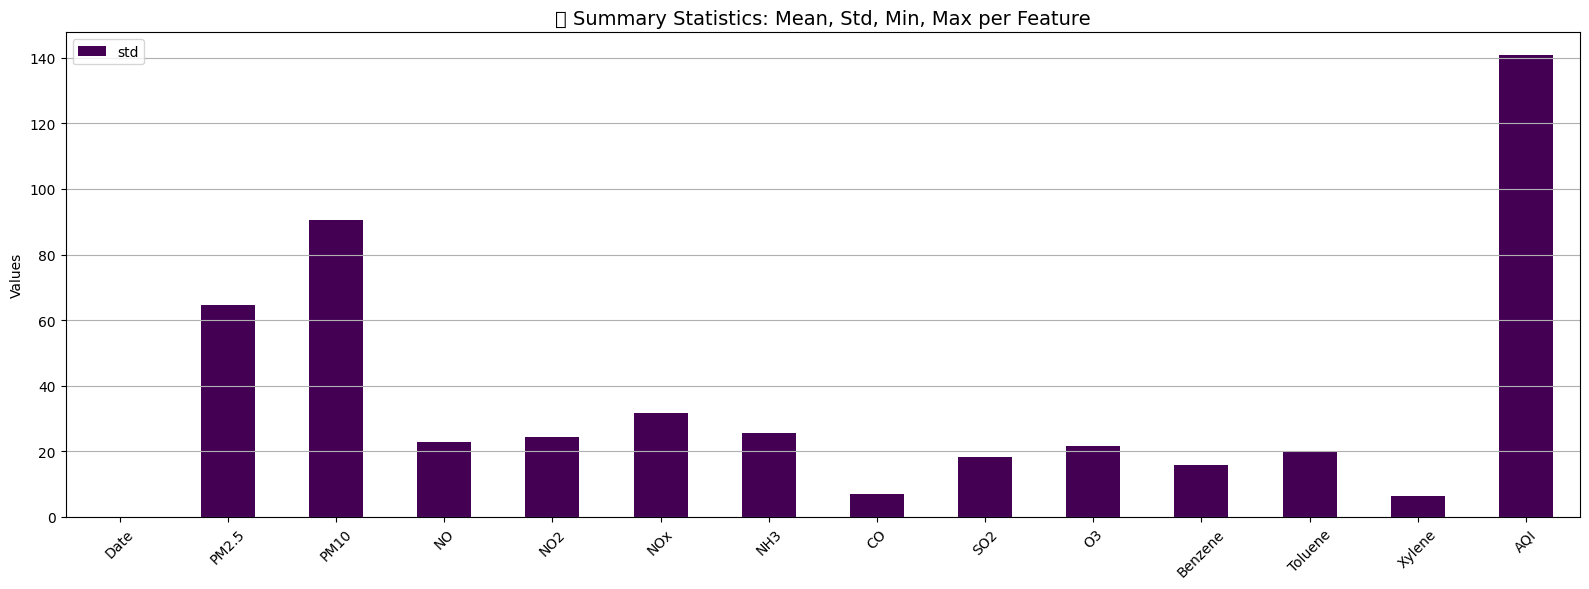

,count,mean,min,25%,50%,75%,max,std
Date,29531,2018-05-14 05:40:15.807118080,2015-01-01 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,67.450578,0.04,28.82,48.57,80.59,949.99,64.661449
PM10,18391.0,118.127103,0.01,56.255,95.68,149.745,1000.0,90.60511
NO,25949.0,17.57473,0.02,5.63,9.89,19.95,390.68,22.785846
NO2,25946.0,28.560659,0.01,11.75,21.69,37.62,362.21,24.474746
NOx,25346.0,32.309123,0.0,12.82,23.52,40.1275,467.63,31.646011
NH3,19203.0,23.483476,0.01,8.58,15.85,30.02,352.89,25.684275
CO,27472.0,2.248598,0.0,0.51,0.89,1.45,175.81,6.962884
SO2,25677.0,14.531977,0.01,5.67,9.16,15.22,193.86,18.133775
O3,25509.0,34.49143,0.01,18.86,30.84,45.57,257.73,21.694928


In [32]:
print("\nSummary Statistics:")


import matplotlib.pyplot as plt
import seaborn as sns

# Get the describe table
summary_stats = df.describe().T[['mean', 'std', 'min', 'max']]

# Plot
summary_stats.plot(kind='bar', figsize=(16, 6), colormap="viridis")
plt.title("📊 Summary Statistics: Mean, Std, Min, Max per Feature", fontsize=14)
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

df.describe().T

In [33]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [34]:
# ----------------------------
# 2. Visualization: Correlation Heatmap and AQI Trend
# ----------------------------
# Correlation Heatmap
# Select only numerical features for correlation calculation

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 🧹 Make sure your 'date' column is in datetime format
##df['Date'] = pd.to_datetime(df['date'], errors='coerce')

# 🎯 Filter data for years 2015 to 2020
df_filtered = df[(df['Date'].dt.year >= 2015) & (df['Date'].dt.year <= 2020)].copy()
df_filtered['year'] = df_filtered['Date'].dt.year

# ✅ Group by year to compute mean AQI
yearly_aqi = df_filtered.groupby('year')['AQI'].mean().reset_index()

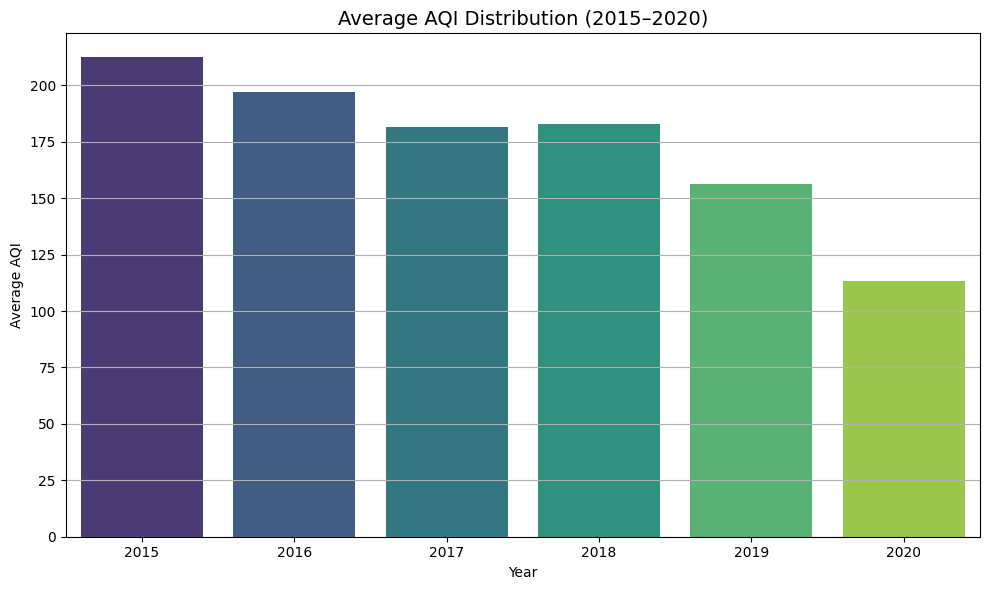

In [35]:
# 1️⃣ Bar plot for average AQI each year
plt.figure(figsize=(10, 6))
sns.barplot(data=yearly_aqi, x='year', y='AQI', palette='viridis')
plt.title("Average AQI Distribution (2015–2020)", fontsize=14)
plt.ylabel("Average AQI")
plt.xlabel("Year")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

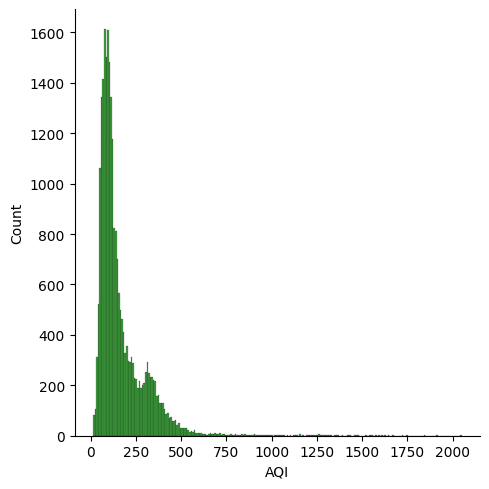

In [36]:
##2️⃣ DISTRUBUTION OF AQI from 2015 to 2020
sns.displot(df,x='AQI',color='green')
plt.show()

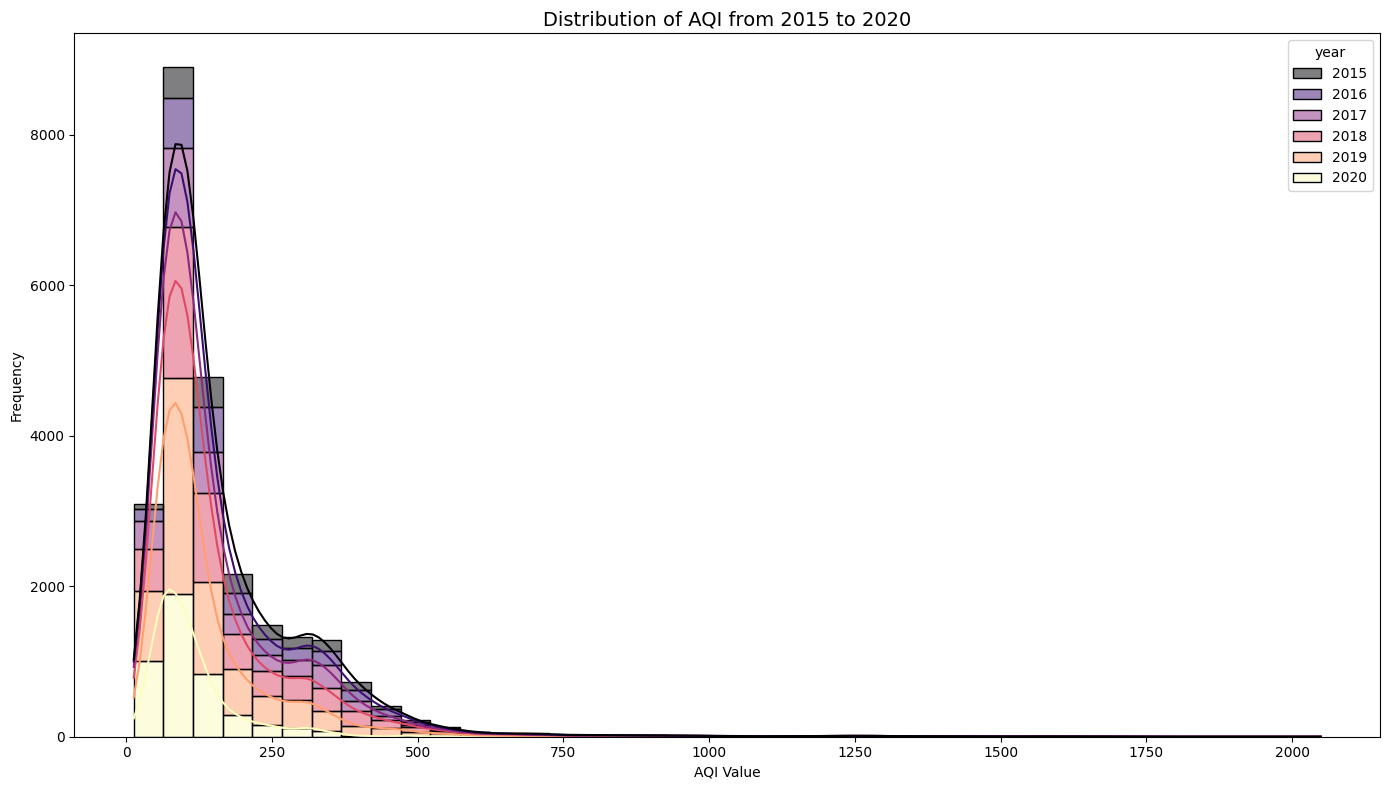

In [37]:
# 🔁 Distribution of AQI across years
plt.figure(figsize=(14, 8))
sns.histplot(data=df_filtered, x='AQI', hue='year', bins=40, kde=True, palette='magma', multiple='stack')
plt.title("Distribution of AQI from 2015 to 2020", fontsize=14)
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

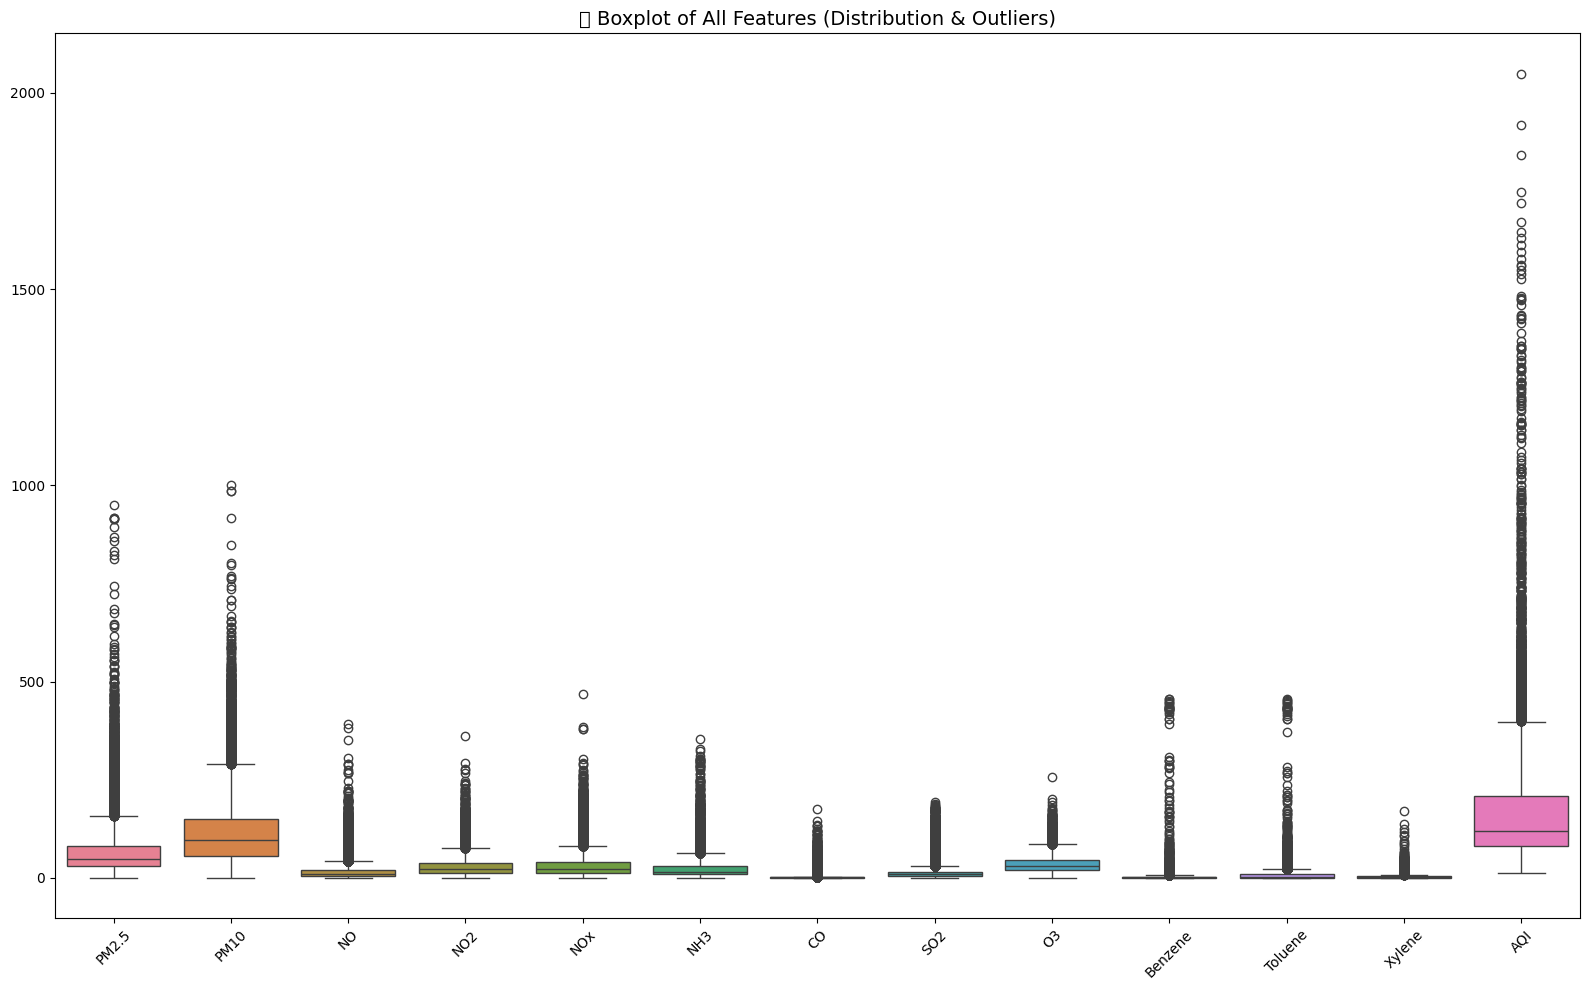

In [38]:
# 4️⃣BOXPLOTS FOR ALL FEATURES
plt.figure(figsize=(16, 10))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("📦 Boxplot of All Features (Distribution & Outliers)", fontsize=14)
plt.tight_layout()
plt.show()


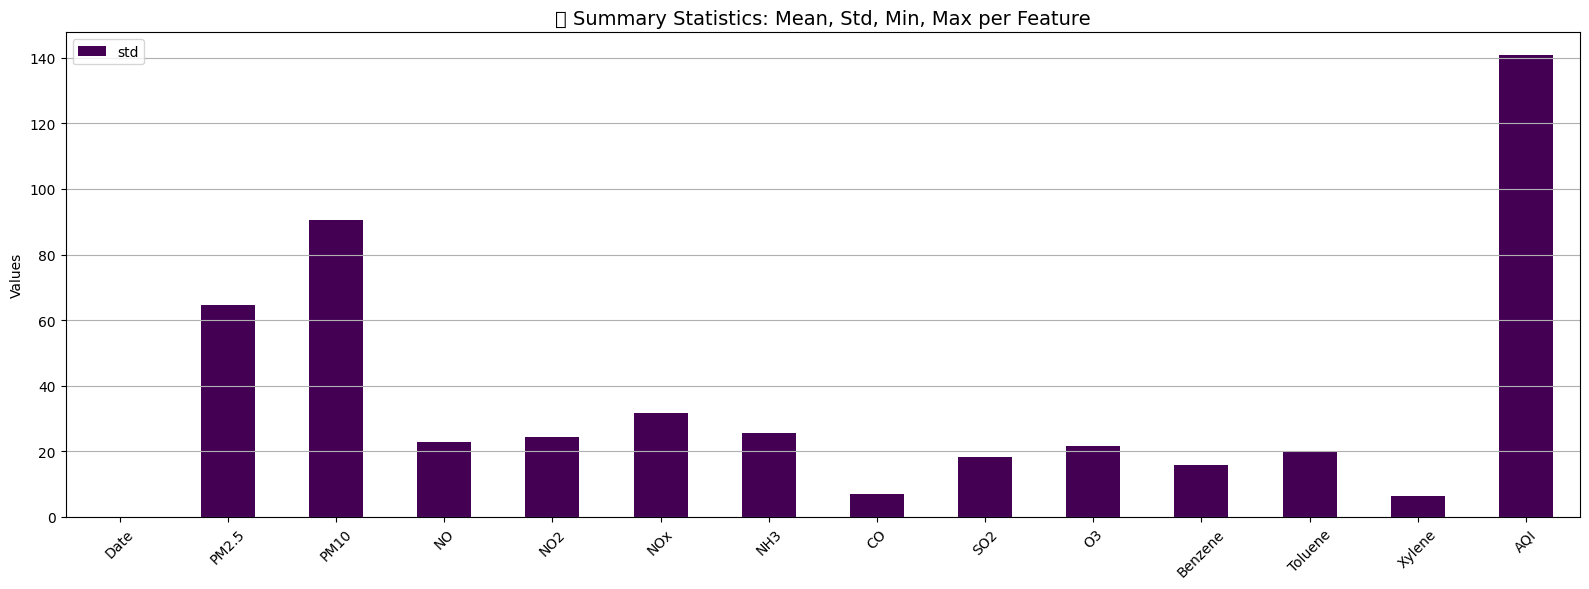

In [39]:
#5️⃣ BARPLOT OF SUMMARY STATISTICS (Mean, Std, Min, Max)
summary_stats = df.describe().T[['mean', 'std', 'min', 'max']]
summary_stats.plot(kind='bar', figsize=(16, 6), colormap="viridis")
plt.title("📊 Summary Statistics: Mean, Std, Min, Max per Feature", fontsize=14)
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

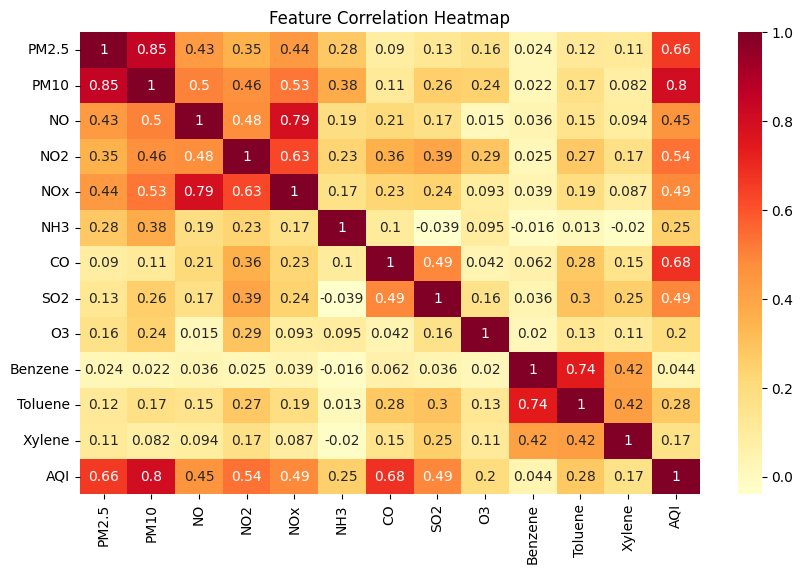

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [40]:
# 36️⃣ HEATMAP OF ALL SUMMARY STATISTICS

plt.figure(figsize=(10,6))
# Select only numerical features for correlation calculation
numerical_features = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='YlOrRd')
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(12, 6))

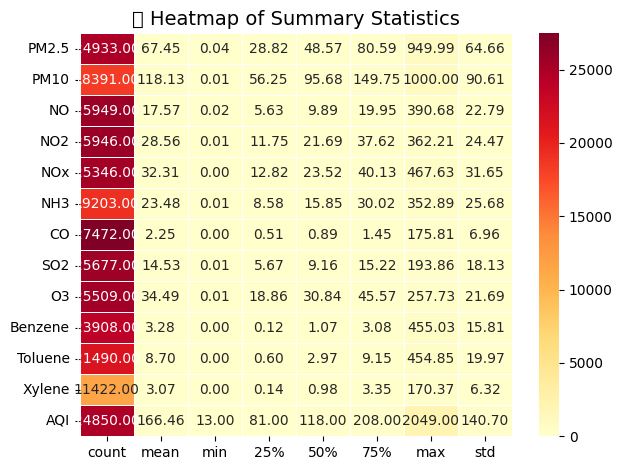

In [41]:
# 7️⃣ Convert the summary statistics to numeric before plotting
num_summary = df.describe().T.drop('Date', axis=0).apply(pd.to_numeric, errors='coerce')
sns.heatmap(num_summary, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=0.5)
plt.title("🔥 Heatmap of Summary Statistics", fontsize=14)
plt.tight_layout()
plt.show()


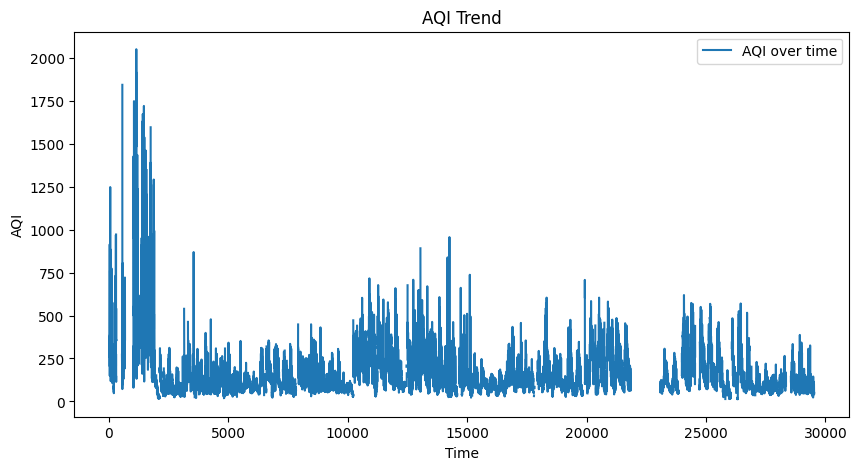

In [42]:
# 8️⃣Plot AQI Trend (Assuming 'AQI' is one of the columns)
plt.figure(figsize=(10,5))
plt.plot(df['AQI'], label='AQI over time')
plt.title("AQI Trend")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [67]:
# ----------------------------
# 3. Feature & Target Setup
# ----------------------------
target_col = 'AQI'
data = df[[target_col]].values

# Scale the data for modeling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create time-sequence data with a sliding window
def create_dataset(dataset, look_back=10):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back, 0])
        y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(y)

look_back = 10
X, y = create_dataset(scaled_data, look_back)

# Train-Test Split (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# For LSTM, reshape to [samples, time steps, features]
X_train_lstm = X_train.reshape(X_train.shape[0], look_back, 1)
X_test_lstm = X_test.reshape(X_test.shape[0], look_back, 1)

# machine learning model
#Linear Regression Model
#Decision Tree Model
#KNeighborsRegressor
#RandomForestRegressor


In [68]:
## 4a------Linear Regression Model--------##########################  PREDICTION  ###############################

# Train-Test Split
from sklearn.model_selection import train_test_split

# Drop non-numeric columns and target column for Linear Regression
X = df.select_dtypes(include=np.number).drop(columns=['AQI', 'Date'], errors='ignore')
y = df['AQI']

# Handle NaN values in X: Option 1 (remove rows with NaN)
# X.dropna(inplace=True)
# y = y[X.index]  # Adjust y accordingly

# Handle NaN values in X and y: Option 2 (imputation with mean)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Impute NaN values in y
y = imputer.fit_transform(y.values.reshape(-1, 1)).ravel() # Reshape and ravel to match original shape


from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # 'X' is your original features

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Evaluation
print("📌 Linear Regression")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_lr)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_lr)))
print("Train R²:", r2_score(y_train, y_pred_train_lr))
print("Test R²:", r2_score(y_test, y_pred_test_lr))

📌 Linear Regression
Train RMSE: 59.654893281536964
Test RMSE: 54.252946838701995
Train R²: 0.7913085061565294
Test R²: 0.804757775353174


In [45]:
#4b  Decision Tree Model--------##########################  PREDICTION  ###############################
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred_train_dt = dt_model.predict(X_train)
y_pred_test_dt = dt_model.predict(X_test)

# Evaluation
print("📌 Decision Tree")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_dt)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_dt)))
print("Train R²:", r2_score(y_train, y_pred_train_dt))
print("Test R²:", r2_score(y_test, y_pred_test_dt))


📌 Decision Tree
Train RMSE: 3.4559466076631424
Test RMSE: 57.298348980659355
Train R²: 0.9992995991731706
Test R²: 0.7822233571048609


In [46]:
#4c  KNeighborsRegressor--------##########################  PREDICTION  ###############################

from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_train_knn = knn_model.predict(X_train)
y_pred_test_knn = knn_model.predict(X_test)

print("📌 KNN")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_knn)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_knn)))
print("Train R²:", r2_score(y_train, y_pred_train_knn))
print("Test R²:", r2_score(y_test, y_pred_test_knn))

📌 KNN
Train RMSE: 41.953565399827795
Test RMSE: 49.597198025969924
Train R²: 0.8967832092843778
Test R²: 0.8368296045385002


In [47]:
#4c  RandomForestRegressor--------##########################  PREDICTION  ###############################
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

print("📌 Random Forest")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train_rf)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test_rf)))
print("Train R²:", r2_score(y_train, y_pred_train_rf))
print("Test R²:", r2_score(y_test, y_pred_test_rf))


📌 Random Forest
Train RMSE: 17.87126918223685
Test RMSE: 41.76649557913025
Train R²: 0.9812706202970356
Test R²: 0.8842867326166856


In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

lr = LinearRegression().fit(X_train, y_train)
dt = DecisionTreeRegressor().fit(X_train, y_train)
rf = RandomForestRegressor().fit(X_train, y_train)
knn = KNeighborsRegressor().fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_dt = dt.predict(X_test)
pred_rf = rf.predict(X_test)
pred_knn = knn.predict(X_test)


Deep learning


In [48]:
##### ANN (Artificial Neural Network)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer='adam', loss='mse')
ann_model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

train_pred_ann = ann_model.predict(X_train).flatten()
test_pred_ann = ann_model.predict(X_test).flatten()

print("📌 ANN")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred_ann)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred_ann)))
print("Train R²:", r2_score(y_train, train_pred_ann))
print("Test R²:", r2_score(y_test, test_pred_ann))

Epoch 1/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8296.4238
Epoch 2/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 2981.3647
Epoch 3/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3203.7908
Epoch 4/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3251.6736
Epoch 5/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3067.6611
Epoch 6/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2747.8188
Epoch 7/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2599.0544
Epoch 8/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2624.4014
Epoch 9/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 2613.7759
Epoch 10/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2422.0356
Epoch 11/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2363.2661
Epoch 12/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2487.4629
Epoch 13/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2447.1196
Epoch 14/50
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - lo

In [49]:
####RNN (Simple RNN Layer)
from tensorflow.keras.layers import SimpleRNN, Reshape

X_rnn = X_lstm  # Already shaped in 3D
y_rnn = y_lstm

X_train_rnn, X_test_rnn = X_rnn[:split], X_rnn[split:]
y_train_rnn, y_test_rnn = y_rnn[:split], y_rnn[split:]

rnn_model = Sequential([
    SimpleRNN(64, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train_rnn, y_train_rnn, epochs=30, batch_size=16, verbose=1)

train_pred_rnn = rnn_model.predict(X_train_rnn)
test_pred_rnn = rnn_model.predict(X_test_rnn)

print("📌 RNN")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_rnn, train_pred_rnn)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_rnn, test_pred_rnn)))
print("Train R²:", r2_score(y_train_rnn, train_pred_rnn))
print("Test R²:", r2_score(y_test_rnn, test_pred_rnn))


Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0095
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0029
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0031
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0030
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0028
Epoch 9/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0025
Epoch 10/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0030
Epoch 11/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0028
Epoch 12/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026
Epoch 13/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025
Epoch 14/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0029
Epoch 15/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

In [50]:
# ----------------------------
# 5. LSTM Model
# ----------------------------
# Ensure X_train_lstm and y_train have the same number of samples
# Adjust the train_size calculation to account for the look_back
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]  # Align y_train with X_train

# Reshape for LSTM, ensuring compatibility
# X_train_lstm = X_train.reshape(X_train.shape[0], look_back, 1)  # Original line causing error

# Calculate the number of features per time step
# num_features_per_timestep = X_train.shape[1] // look_back  # Original line causing error
num_features_per_timestep = X_train.shape[1] # calculate the number of features

# Reshape, taking into account the calculated features per timestep
X_train_lstm = X_train.reshape(X_train.shape[0], 1, num_features_per_timestep) # reshape to (samples, timesteps, features)
X_test_lstm = X_test.reshape(X_test.shape[0], 1, num_features_per_timestep) # reshape to (samples, timesteps, features)

In [69]:
# 5a. LSTM Model--------##########################  PREDICTION  ###############################

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Select only numerical features for scaling
numerical_features = df.select_dtypes(include=np.number).drop(columns=['Date'], errors='ignore').columns

# Scale numerical features
scaler = MinMaxScaler()

# Handle NaN values before scaling
# Option 1: Remove rows with NaN
df_cleaned = df[numerical_features].dropna()

# Option 2: Impute NaN with mean/median/mode (choose one)
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')  # Or 'median', 'most_frequent'
# df_cleaned = pd.DataFrame(imputer.fit_transform(df[numerical_features]), columns=numerical_features)

scaled_data = scaler.fit_transform(df_cleaned)

# Prepare features and target
X_lstm = []
y_lstm = []

window = 10
for i in range(window, len(scaled_data)):
    X_lstm.append(scaled_data[i-window:i, :-1])  # All features except AQI
    y_lstm.append(scaled_data[i, -1])  # AQI is the last column

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Train-test split
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# LSTM Model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])))
model.add(Dropout(0.2))  # Prevent overfitting
model.add(Dense(32, activation='relu'))  # Extra Dense layer
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train.reshape(X_train.shape[0], 1, X_train.shape[1]), y_train,
          epochs=100, batch_size=16, validation_split=0.2)


# Train
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, verbose=1)

# Predict
train_pred_lstm = model.predict(X_train_lstm)
test_pred_lstm = model.predict(X_test_lstm)

# Inverse transform (use df_cleaned for inverse transform)
train_actual = scaler.inverse_transform(
    np.concatenate([X_train_lstm[:, -1], train_pred_lstm], axis=1))[:, -1]
test_actual = scaler.inverse_transform(
    np.concatenate([X_test_lstm[:, -1], test_pred_lstm], axis=1))[:, -1]
y_train_real = scaler.inverse_transform(
    np.concatenate([X_train_lstm[:, -1], y_train_lstm.reshape(-1, 1)], axis=1))[:, -1]
y_test_real = scaler.inverse_transform(
    np.concatenate([X_test_lstm[:, -1], y_test_lstm.reshape(-1, 1)], axis=1))[:, -1]

# Evaluation
print("📌 LSTM")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train_real, train_actual)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_real, test_actual)))
print("Train R²:", r2_score(y_train_real, train_actual))
print("Test R²:", r2_score(y_test_real, test_actual))

Epoch 1/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 26008.7617 - val_loss: 7713.2954
Epoch 2/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 8078.7134 - val_loss: 5041.0410
Epoch 3/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 5352.4316 - val_loss: 4250.3511
Epoch 4/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 4376.3345 - val_loss: 3565.7451
Epoch 5/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4126.6475 - val_loss: 3261.4651
Epoch 6/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 3716.0938 - val_loss: 3411.3083
Epoch 7/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3841.5815 - val_loss: 3531.3755
Epoch 8/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 4138.4175 - val_loss: 3348.7241
Epoch 9/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 3301.8589 - val_loss: 3610.8203
Epoch 10/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3620.2073 - val_loss: 3506.6145
Epoch 11/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 6s 

In [86]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
import numpy as np

# Reshape for RNN & LSTM
X_train_rnn = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# 👩‍💻 ANN
ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(1)
])
ann.compile(optimizer='adam', loss='mse')
ann.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)  # ⏱️ Reduced epochs + bigger batch
pred_ann = ann.predict(X_test).flatten()

# 🔁 RNN
rnn = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.1),
    Dense(1)
])
rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train_rnn, y_train, epochs=10, batch_size=64, verbose=0)
pred_rnn = rnn.predict(X_test_rnn).flatten()

# 🔁 LSTM
lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.1),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_rnn, y_train, epochs=10, batch_size=64, verbose=0)
pred_lstm = lstm.predict(X_test_rnn).flatten()





185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [88]:
## ----------------------------
# 6. Ensemble Blending of Predictions
# ----------------------------


import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Store predictions from previous models (Make sure you have run the previous model cells)
pred_lr = lr_model.predict(X_test)  # Linear Regression predictions
pred_dt = dt_model.predict(X_test)  # Decision Tree predictions
pred_knn = knn_model.predict(X_test) # KNN predictions
pred_rf = rf_model.predict(X_test)  # Random Forest predictions
pred_ann = ann_model.predict(X_test).flatten()  # ANN predictions
pred_lstm = test_actual  # LSTM predictions (from cell 51)
pred_rnn = rnn_model.predict(X_test_rnn)  # RNN predictions


# STEP 1: Find the minimum common length across all predictions
min_len = min(len(pred_lr), len(pred_dt), len(pred_knn), len(pred_rf),
              len(pred_ann), len(pred_lstm), len(pred_rnn), len(y_test))

# STEP 2: Trim all predictions and actual to same length
pred_lr = pred_lr[:min_len]
pred_dt = pred_dt[:min_len]
pred_knn = pred_knn[:min_len]
pred_rf = pred_rf[:min_len]
pred_ann = pred_ann[:min_len]
pred_lstm = pred_lstm[:min_len]

# Reshape pred_rnn to have the same number of dimensions as other predictions
pred_rnn = pred_rnn[:min_len].reshape(-1)

y_test_trimmed = y_test[:min_len]

# STEP 3: Blended ensemble (simple average)
ensemble_pred = (pred_lr + pred_dt + pred_knn + pred_rf +
                 pred_ann + pred_lstm + pred_rnn) / 7


185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step



✅ Linear Regression Performance:
MAE     : 32.10112848873185
MSE     : 3666.6987398864117
RMSE    : 60.553271917266464
R²      : 0.7595332311271827
Accuracy   : 0.05698234349919743
Precision  : 0.1440405092090485
Recall     : 0.05698234349919743
F1 Score   : 0.08047056333337138

✅ Decision Tree Performance:
MAE     : 27.792219249840112
MSE     : 2402.654365308101
RMSE    : 49.01687837172111
R²      : 0.842430869583328
Accuracy   : 0.10834670947030497
Precision  : 0.14518498155135395
Recall     : 0.10834670947030497
F1 Score   : 0.12146478267736097

✅ KNN Performance:
MAE     : 22.95994503134376
MSE     : 2179.898119374638
RMSE    : 46.689379085340576
R²      : 0.85703950762691
Accuracy   : 0.13804173354735153
Precision  : 0.17321727345629923
Recall     : 0.13804173354735153
F1 Score   : 0.1523086618824559

✅ Random Forest Performance:
MAE     : 19.98276647842921
MSE     : 1434.4117759378555
RMSE    : 37.87362903047258
R²      : 0.9059294505870474
Accuracy   : 0.09149277688603531
Preci

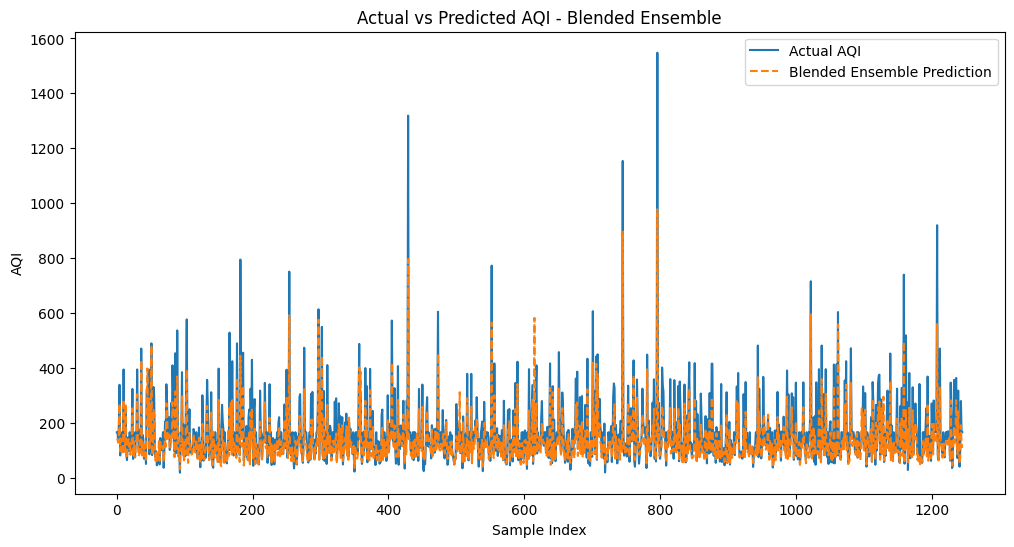

In [97]:
# ================================
# ✅ 7. Evaluation Metrics
# ================================

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)

def print_metrics(y_true, y_pred, model_name="Model"):
    print(f"\n✅ {model_name} Performance:")
    print("MAE     :", mean_absolute_error(y_true, y_pred))
    print("MSE     :", mean_squared_error(y_true, y_pred))
    print("RMSE    :", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R²      :", r2_score(y_true, y_pred))

    # 👇 For classification metrics (rounded predictions)
    try:
        y_pred_class = np.round(y_pred).astype(int)
        y_true_class = np.round(y_true).astype(int)

        print("Accuracy   :", accuracy_score(y_true_class, y_pred_class))
        print("Precision  :", precision_score(y_true_class, y_pred_class, average='weighted', zero_division=0))
        print("Recall     :", recall_score(y_true_class, y_pred_class, average='weighted', zero_division=0))
        print("F1 Score   :", f1_score(y_true_class, y_pred_class, average='weighted', zero_division=0))
    except:
        print("⚠️ Classification metrics could not be computed (non-integer targets?)")


# Evaluate each model
print_metrics(y_test_trimmed, pred_lr, "Linear Regression")
print_metrics(y_test_trimmed, pred_dt, "Decision Tree")
print_metrics(y_test_trimmed, pred_knn, "KNN")
print_metrics(y_test_trimmed, pred_rf, "Random Forest")
print_metrics(y_test_trimmed, pred_ann, "ANN")
print_metrics(y_test_trimmed, pred_lstm, "LSTM")
print_metrics(y_test_trimmed, pred_rnn, "RNN")
print_metrics(y_test_trimmed, ensemble_pred, "❤️❤️❤️❤️❤️Blended Ensemble❤️❤️❤️❤️❤️")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test_trimmed, label='Actual AQI')
plt.plot(ensemble_pred, label='Blended Ensemble Prediction', linestyle='--')
plt.title("Actual vs Predicted AQI - Blended Ensemble")
plt.xlabel("Sample Index")
plt.ylabel("AQI")
plt.legend()
plt.show()

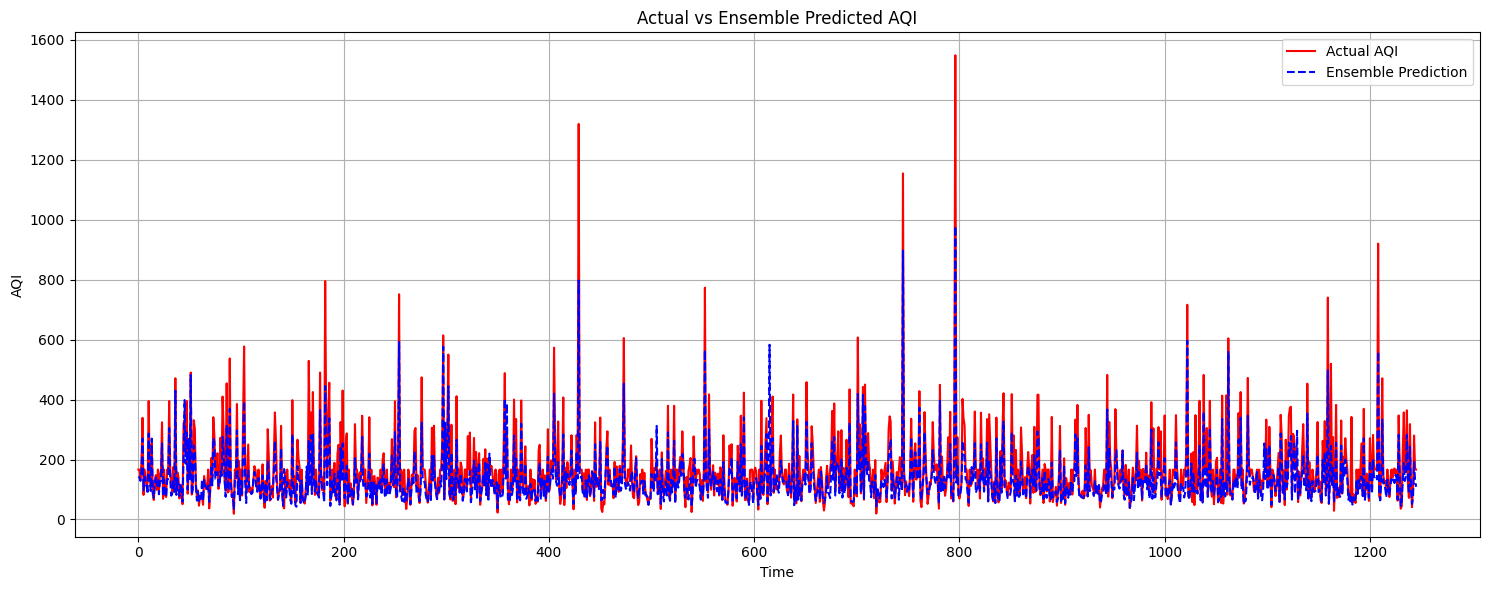

In [98]:
# ================================
# ✅ 8. Visualization: Actual vs Predicted AQI
# ================================
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt # Add this import
plt.figure(figsize=(15,6))
plt.plot(y_test_trimmed, label='Actual AQI', color='red')
plt.plot(ensemble_pred, label='Ensemble Prediction', color='blue', linestyle='dashed')
plt.title('Actual vs Ensemble Predicted AQI')
plt.xlabel('Time')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


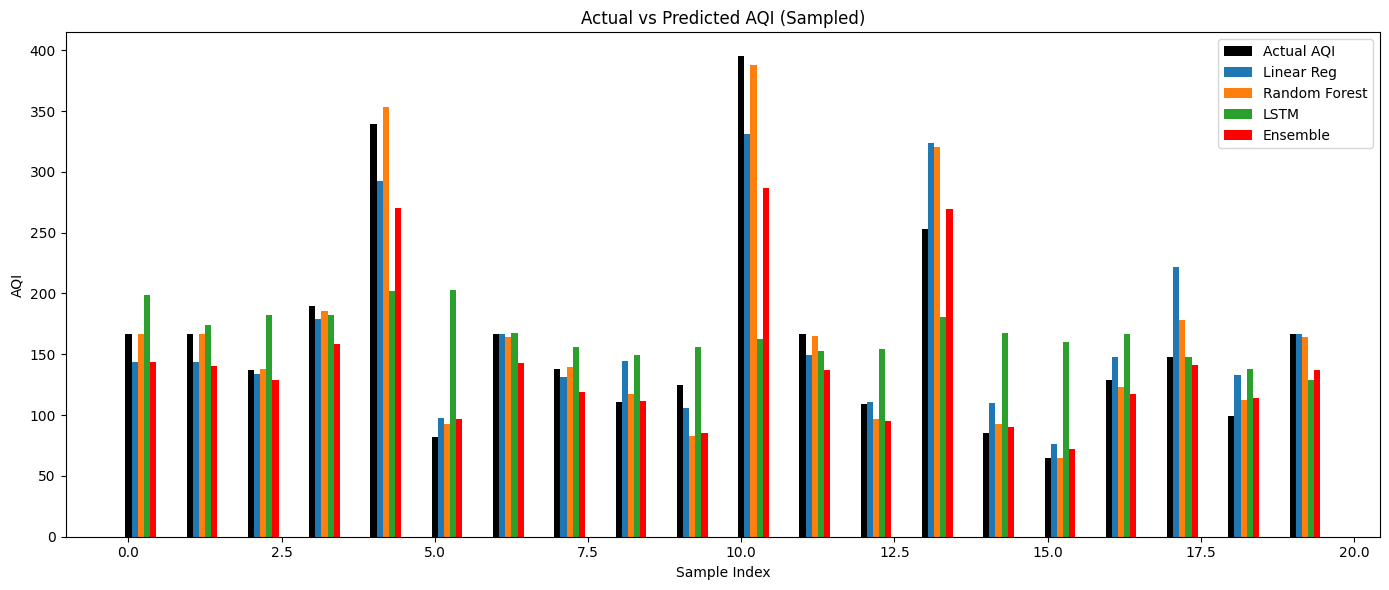

In [99]:
import numpy as np

# Take a small slice to visualize better
sample_indices = np.arange(20)

plt.figure(figsize=(14, 6))
bar_width = 0.1

plt.bar(sample_indices, y_test[:20], width=bar_width, label='Actual AQI', color='black')
plt.bar(sample_indices + bar_width, pred_lr[:20], width=bar_width, label='Linear Reg')
plt.bar(sample_indices + 2*bar_width, pred_rf[:20], width=bar_width, label='Random Forest')
plt.bar(sample_indices + 3*bar_width, pred_lstm[:20], width=bar_width, label='LSTM')
plt.bar(sample_indices + 4*bar_width, ensemble_pred[:20], width=bar_width, label='Ensemble', color='red')

plt.title('Actual vs Predicted AQI (Sampled)')
plt.xlabel('Sample Index')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()


In [101]:
# Calculate absolute and percentage error
import pandas as pd

# Create comparison_df from y_test_trimmed and ensemble_pred
comparison_df = pd.DataFrame({'Actual': y_test_trimmed, 'Predicted': ensemble_pred})

comparison_df['Absolute Error'] = abs(comparison_df['Actual'] - comparison_df['Predicted'])
comparison_df['Percentage Error'] = (comparison_df['Absolute Error'] / comparison_df['Actual']) * 100

# Calculate and print the average error percentage
avg_error = comparison_df['Percentage Error'].mean()
print(f"\n📉 Average Error Percentage: {avg_error:.2f}%")


📉 Average Error Percentage: 21.05%
